# Common Design Patterns

This guide presents recurring design patterns that kfactory users apply when
building real PDKs.  Each pattern is a self-contained recipe you can adapt.

**Contents**

1. [Component composition](#1-component-composition)
2. [Port propagation through hierarchy](#2-port-propagation-through-hierarchy)
3. [Factory bundle (dataclass)](#3-factory-bundle-dataclass)
4. [Cross-section lookup in cached cells](#4-cross-section-lookup-in-cached-cells)
5. [Tile / array pattern](#5-tile-array-pattern)
6. [VKCell route → KCell materialise](#6-vkcell-route-kcell-materialise)

In [1]:
import dataclasses
import kfactory as kf
from kfactory.factories.straight import straight_dbu_factory
from kfactory.factories.euler import bend_euler_factory

# Shared layers for all examples in this notebook
class LAYER(kf.LayerInfos):
    WG:   kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)

pdk = kf.KCLayout("patterns_pdk", infos=LAYER)
L = pdk.infos
# li_* = integer layer indices (for direct shape insertion / port construction)
li_wg   = pdk.find_layer(L.WG)
li_wgex = pdk.find_layer(L.WGEX)

enc = pdk.get_enclosure(kf.LayerEnclosure(
    name="WG_EX",
    main_layer=kf.kdb.LayerInfo(1, 0),
    sections=[(kf.kdb.LayerInfo(2, 0), 2000)],
))

# Factory callables accept kdb.LayerInfo objects, not integer indices
straight   = straight_dbu_factory(pdk)
bend_euler = bend_euler_factory(pdk)

---
## 1 · Component composition

Build complex cells from simpler primitives using the **instance-and-connect**
pattern.  Each primitive is created once (cached by `@kf.cell`) and reused.

The recipe:
1. Create the parent cell.
2. Instantiate child cells with `<<`.
3. Connect the first instance to a fixed position; use `connect()` for the rest.
4. Expose the external ports on the parent.

ports: ['o1', 'o2']


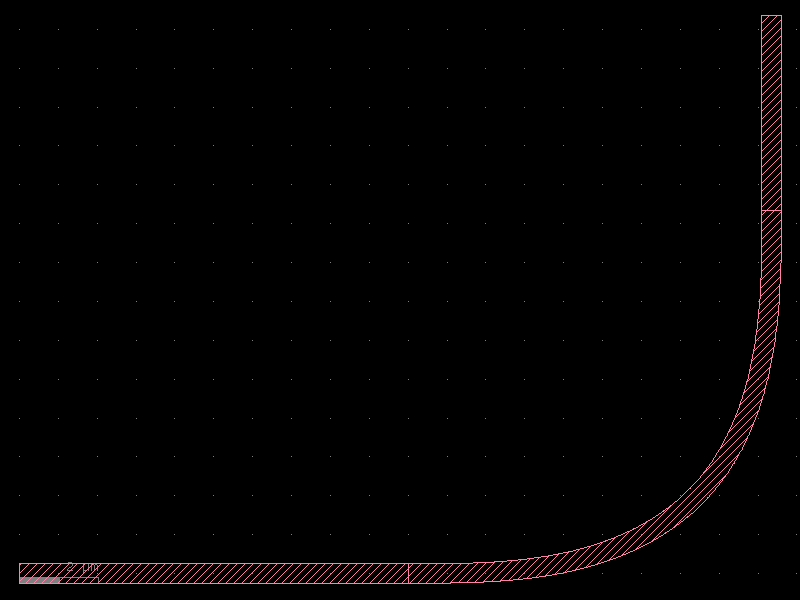

In [2]:
@pdk.cell
def l_arm(
    width: float = 0.5,
    length1: float = 10.0,
    length2: float = 5.0,
    radius: float = 5.0,
) -> kf.KCell:
    """L-shaped arm: straight → 90° euler bend → straight."""
    c = kf.KCell(kcl=pdk)

    w_dbu  = pdk.to_dbu(width)
    l1_dbu = pdk.to_dbu(length1)
    l2_dbu = pdk.to_dbu(length2)

    # Primitives (cached — same params reuse the same cell object)
    s1 = straight(width=w_dbu, length=l1_dbu, layer=L.WG)
    b  = bend_euler(width=width, radius=radius, layer=L.WG)
    s2 = straight(width=w_dbu, length=l2_dbu, layer=L.WG)

    # Instantiate and chain
    i1 = c << s1
    i_b = c << b
    i2  = c << s2

    i_b.connect("o1", i1.ports["o2"])
    i2.connect("o1", i_b.ports["o2"])

    # Expose external ports
    c.add_port(port=i1.ports["o1"], name="o1")
    c.add_port(port=i2.ports["o2"], name="o2")
    return c


arm = l_arm()
print(f"ports: {[p.name for p in arm.ports]}")
arm.plot()

---
## 2 · Port propagation through hierarchy

When a cell wraps several children you need to surface the right ports to the
caller.  Two sub-patterns cover most cases:

**a) Direct exposure** — forward the child port unchanged:

```python
c.add_port(port=inst.ports["o1"], name="in")
```

**b) Bulk exposure with auto-renaming** — expose all ports with a prefix:

```python
c.add_ports(inst.ports, prefix="left_")
```

The example below builds a Mach-Zehnder skeleton and exposes four ports
(`in`, `out`, `arm_top_in`, `arm_top_out`).

In [3]:
@pdk.cell
def mz_skeleton(
    width: float = 0.5,
    arm_length: float = 20.0,
    radius: float = 5.0,
) -> kf.KCell:
    """Mach-Zehnder skeleton with exposed arm ports."""
    c = kf.KCell(kcl=pdk)

    w_dbu = pdk.to_dbu(width)
    al_dbu = pdk.to_dbu(arm_length)

    s_in  = straight(width=w_dbu, length=pdk.to_dbu(5.0), layer=L.WG)
    s_arm = straight(width=w_dbu, length=al_dbu, layer=L.WG)

    # Bottom arm
    i_in  = c << s_in
    i_arm = c << s_arm
    i_arm.connect("o1", i_in.ports["o2"])
    i_out = c << s_in
    i_out.connect("o1", i_arm.ports["o2"])

    # Top arm (offset upward by 2 × radius µm)
    i_arm_top = c << s_arm
    i_arm_top.dmove((0.0, radius * 2))  # pure µm offset

    # a) Direct port exposure with rename
    c.add_port(port=i_in.ports["o1"],   name="in")
    c.add_port(port=i_out.ports["o2"],  name="out")

    # b) Individual port exposure for arm access points
    c.add_port(port=i_arm_top.ports["o1"], name="arm_top_in")
    c.add_port(port=i_arm_top.ports["o2"], name="arm_top_out")

    return c


mz = mz_skeleton()
print(f"ports: {[p.name for p in mz.ports]}")

ports: ['in', 'out', 'arm_top_in', 'arm_top_out']


---
## 3 · Factory bundle (dataclass)

As a PDK grows it becomes hard to pass individual factory functions around.
The **factory bundle** pattern collects all factories into a frozen `dataclass`
that can be imported as a single object.

`KCLayout` does not provide built-in slots for factories, so use a dataclass at
module level instead.

In [4]:
from kfactory.factories.straight import StraightFactory
from kfactory.factories.euler import BendEulerFactory


@dataclasses.dataclass(frozen=True)
class PDKFactories:
    straight:   StraightFactory
    bend_euler: BendEulerFactory


# Build once at module level, import everywhere.
factories = PDKFactories(
    straight   = straight_dbu_factory(pdk),
    bend_euler = bend_euler_factory(pdk),
)

# Usage — cells receive the bundle, not the individual factories:
@pdk.cell
def my_component(width: float = 0.5, length: float = 10.0) -> kf.KCell:
    c = kf.KCell(kcl=pdk)
    w_dbu = pdk.to_dbu(width)
    s = factories.straight(width=w_dbu, length=pdk.to_dbu(length), layer=L.WG)
    inst = c << s
    c.add_port(port=inst.ports["o1"], name="o1")
    c.add_port(port=inst.ports["o2"], name="o2")
    return c


comp = my_component()
print(f"cell: {comp.name}")
print(f"factory bundle type: {type(factories)}")

2026-05-05 10:52:34.982 | ERROR    | kfactory.kcell:name:700 - Name conflict in kfactory.kcell::name at line 700
Renaming Unnamed_8 (cell_index=8) to straight_W500_L10000_LWG_ENone would cause it to be named the same as:
 - straight_W500_L10000_LWG_ENone (cell_index=1), function_name=straight, basename=None


cell: my_component_W0p5_L10
factory bundle type: <class '__main__.PDKFactories'>


---
## 4 · Cross-section lookup in cached cells

`@pdk.cell` (and `@kf.cell`) require **hashable** arguments.  A
`CrossSection` object is not hashable, so you cannot pass one directly as a
parameter.

The standard pattern is:
1. Register cross-sections on the PDK once at module level.
2. Accept a **name string** as the cell parameter.
3. Look up the actual `CrossSection` inside the cell body.

In [5]:
from kfactory.cross_section import SymmetricalCrossSection

# Register once
xs_wg = SymmetricalCrossSection(
    width=pdk.to_dbu(0.5),
    enclosure=enc,
    name="WG",
)
pdk.get_icross_section(xs_wg)   # registers and returns it (idempotent)

xs_wide = SymmetricalCrossSection(
    width=pdk.to_dbu(1.0),
    enclosure=enc,
    name="WG_WIDE",
)
pdk.get_icross_section(xs_wide)


@pdk.cell
def wg_with_xs(xs_name: str = "WG", length: float = 10.0) -> kf.KCell:
    """Straight waveguide parameterised by cross-section name."""
    xs = pdk.get_icross_section(xs_name)   # ← lookup inside the cell body
    c  = kf.KCell(kcl=pdk)
    l_dbu = pdk.to_dbu(length)
    c.shapes(li_wg).insert(kf.kdb.Box(l_dbu, xs.width))
    c.add_port(port=kf.Port(
        name="o1",
        trans=kf.kdb.Trans(2, False, -l_dbu // 2, 0),
        width=xs.width, layer=li_wg, port_type="optical", kcl=pdk,
    ))
    c.add_port(port=kf.Port(
        name="o2",
        trans=kf.kdb.Trans(0, False,  l_dbu // 2, 0),
        width=xs.width, layer=li_wg, port_type="optical", kcl=pdk,
    ))
    return c


wg_std  = wg_with_xs(xs_name="WG")
wg_wide = wg_with_xs(xs_name="WG_WIDE")
print(f"WG width (DBU):      {pdk.get_icross_section('WG').width}")
print(f"WG_WIDE width (DBU): {pdk.get_icross_section('WG_WIDE').width}")

WG width (DBU):      500
WG_WIDE width (DBU): 1000


---
## 5 · Tile / array pattern

Use `kf.grid_dbu` (for `KCell`) or `kf.grid` (for `DKCell`) to arrange a
collection of cells in a regular grid.  This is useful for test structures,
component galleries, and fill tiles.

Key points:

| Function | Input cells | Coordinates |
|---|---|---|
| `kf.grid_dbu` | `KCell` (DBU) | DBU integers |
| `kf.grid` | `DKCell` (µm) | float µm |

The `shape=(rows, cols)` parameter sets the grid dimensions.

grid cell name: wg_array
grid bbox (µm): (0,2.75;21,8.75)


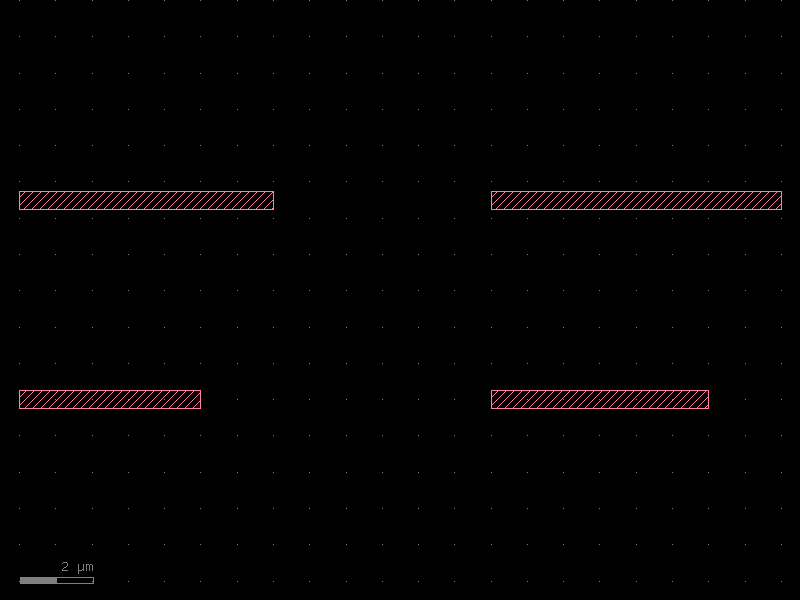

In [6]:
# Build a small set of components to tile
components = [
    wg_with_xs(xs_name="WG", length=float(5 + i))
    for i in range(4)
]

# grid_dbu places cells into a target KCell and returns an InstanceGroup
target = kf.KCell("wg_array", kcl=pdk)
kf.grid_dbu(
    target,
    kcells=components,
    spacing=pdk.to_dbu(5.0),
    shape=(2, 2),
    align_x="xmin",
    align_y="ymin",
)
print(f"grid cell name: {target.name}")
print(f"grid bbox (µm): {target.dbbox()}")
target.plot()

---
## 6 · VKCell route → KCell materialise

All-angle routing produces a **virtual** route (a `VKCell`).  The pattern to
turn it into a permanent `KCell` is:

1. Create the target cell.
2. Build a `VKCell` with virtual straight / bend factories.
3. Call `kf.routing.aa.optical.route()` to fill the `VKCell`.
4. Insert the virtual instance into the target cell with `VInstance.insert_into()`.

This keeps the route geometry isolated until you explicitly materialise it.

cell: aa_vkcell_pattern
bbox (µm): (0,-0.25;160,60.25)


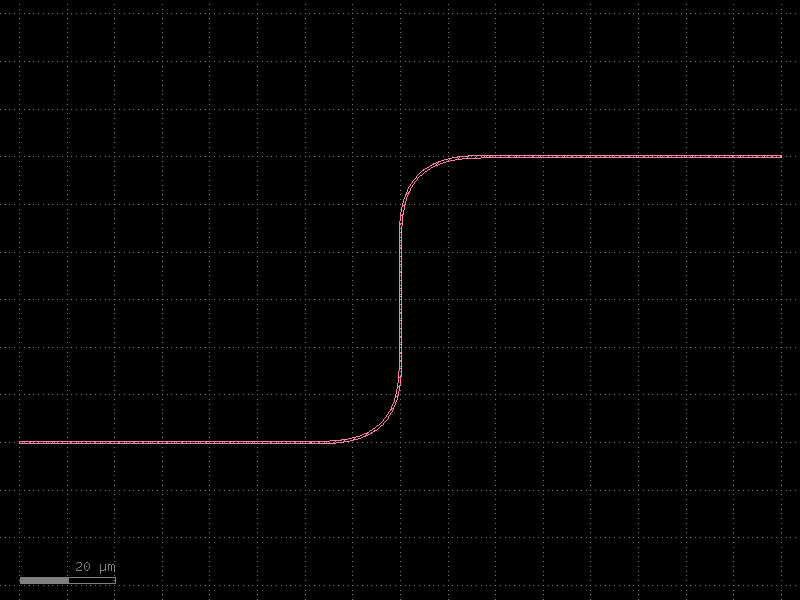

In [7]:
import kfactory.routing.aa.optical as aa
from functools import partial
from kfactory.factories.virtual.straight import virtual_straight_factory
from kfactory.factories.virtual.euler import virtual_bend_euler_factory

# Virtual factories are pre-configured with partial() — bind layer/width/radius
_v_straight_raw = virtual_straight_factory(kcl=pdk)
_v_bend_raw     = virtual_bend_euler_factory(kcl=pdk)

v_straight = partial(_v_straight_raw, layer=L.WG)
v_bend     = partial(_v_bend_raw, width=0.5, radius=10.0, layer=L.WG)

# Step 1 — route into a VKCell (virtual; geometry stays in-memory only)
# Create the VKCell via the PDK's KCLayout so layer indices match
vc = pdk.vkcell(name="aa_vkcell_demo")
aa.route(
    vc,
    width=0.5,
    backbone=[
        kf.kdb.DPoint(0, 0),
        kf.kdb.DPoint(80, 0),    # horizontal
        kf.kdb.DPoint(80, 60),   # 90° corner upward
        kf.kdb.DPoint(160, 60),  # horizontal to exit
    ],
    straight_factory=v_straight,
    bend_factory=v_bend,
)

# Step 2 — materialise into a real KCell
c_routed = kf.KCell("aa_vkcell_pattern", kcl=pdk)
vi = kf.VInstance(vc)
vi.insert_into(c_routed)

print(f"cell: {c_routed.name}")
print(f"bbox (µm): {c_routed.dbbox()}")
c_routed.plot()

## See Also

| Topic | Where |
|-------|-------|
| Common pitfalls to avoid | [How-To: Best Practices](best_practices.py) |
| Frequently asked questions | [How-To: FAQ](faq.md) |
| PCells & caching | [Components: PCells](../components/cells/pcells.py) |
| Routing overview | [Routing: Overview](../routing/overview.py) |